# Customer Churn Analysis
-----------------------
This project attempts to predict customer churn of a UK-based online retail based on sales data between Dec 1, 2009 to Dec 9, 2011. The retailer primarily sells all-occasion gift-ware with many of the customers being wholesalers. 

The objective is to determine if churn can be reliably predicted & retention interventions targeted to a subset of customers, informed exclusively by order history. Churn is predicted using two binary classifcation models: 1. Logistic Regression & 2. Gradient Boosting Classification. 

The result were that although both models provided some explanatory power, neither were sufficent in reliably predict customer churn, even when the scope was narrowed to 'higher confidence' customers.



Data Sorce - UC Irvine Machine Learning Repository (Online Retail II) : https://archive.ics.uci.edu/dataset/502/online+retail+ii


In [ ]:
# Import Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
from datetime import datetime, timedelta
from scipy.stats import loguniform, randint, uniform, skew
import statsmodels.api as sm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, average_precision_score, classification_report
from sklearn.model_selection import cross_val_score, StratifiedKFold
import shap

#import scikit-learn
#import jupyterlab
#import xgboost

# Set Display Preferences
pd.set_option('display.max_columns', None)
pd.options.display.float_format = "{:.2f}".format
np.random.seed(1)

/opt/miniconda3/envs/churn_prediction/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Load data & remove duplicate entries

In [2]:
### UK Based ecom retailer sales from Jan 12, 2009 to Sep 12, 2011.
### Mainly sells unique all-occasion gift-ware.
df1 = pd.read_excel("data/online_retail_II.xlsx", sheet_name='Year 2009-2010', header=0)
df2 = pd.read_excel("data/online_retail_II.xlsx", sheet_name='Year 2010-2011', header=0)

### Note: Both excel sheets contain 2010 sales. Duplicates must be removed before concatenating.
# There is 1 week of overlap in the datasets
print('End date of File 1:', df1['InvoiceDate'].max())
print('Start date of File 2:',df2['InvoiceDate'].min())

# Remove duplicate entries 
df1 = df1[~df1["Invoice"].isin(df2['Invoice'].unique())]
# Note: achives identical result as -> df1[df1['InvoiceDate']<df2['InvoiceDate'].min()] 

### Merge the dataframes from each year
df = pd.concat([df1, df2], axis=0, ignore_index=True)

### Remove time component from Invoice Date
df['InvoiceDate'] = df['InvoiceDate'].dt.date

df_orig = df.copy()

End date of File 1: 2010-12-09 20:01:00
Start date of File 2: 2010-12-01 08:26:00


# Data Processing & Feature Engineering
--------------------------------

## Data Processiong  
 Remove null customer IDs & non-purchase invoice entries (unit price of $0 or invalid stock codes).

In [3]:
### Null Customer IDs (required to determine churn). 
### Reason for missing Customer ID is unknown. For simplicity, these entries will be excluded from the analysis. This likely creates a source of bias.
### Recomendation is to update the ordering platform to require purchasers to create an account & generate a unique Customer ID.
null_id_pct = sum(df['Customer ID'].isnull()) / len(df)
print(f'Percent of entries that are missing Customer ID: {null_id_pct*100:.2f}%')

### Some items have a price of $0. These entries will not count towards orders.
### Primarily consisting of stickers, car flags, shipping materials & invoice notes.
non_items = len(df[df['Price']==0]) / len(df)
print(f'Percent of entries that had a price of $0: {non_items*100:.2f}%')

### Examining the Stock Codes, entries starting with alphabetic characters are atypical invoice entries that do not represent merchandise sales.
### Ex. Test products, adjustments, postage, carriage, etc.
df["StockCode"] = df["StockCode"].astype(str)
stockcode = (
    df.groupby(["StockCode", "Description"])["Quantity"]
      .sum()
      .reset_index()        
      .sort_values("StockCode", ascending=False)
    )

stockcode_pct = sum(~df['StockCode'].str.match(r'^\d')) / len(df)
print(f'Percent of entries that have invalid Stock Codes: {stockcode_pct*100:.2f}%')

### Remove entries is no Customer ID, Price = $0, or  entries for Stock Codes beginning with alphabetic characters
df = df[~df['Customer ID'].isnull()]
df = df[df['Price']!=0]
df = df[df['StockCode'].str.match(r'^\d')]
df

Percent of entries that are missing Customer ID: 22.52%
Percent of entries that had a price of $0: 0.58%
Percent of entries that have invalid Stock Codes: 0.57%


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01,6.95,13085.00,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01,6.75,13085.00,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01,6.75,13085.00,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01,2.10,13085.00,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01,1.25,13085.00,United Kingdom
...,...,...,...,...,...,...,...,...
1044842,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09,0.85,12680.00,France
1044843,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09,2.10,12680.00,France
1044844,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09,4.15,12680.00,France
1044845,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09,4.15,12680.00,France


## Feature Engineering
Basic Features:
- Invoice Amount: Price * Quantity
- UK_Ind: Binary variable - (1 if order country is UK, else 0)

Aggregation Features - Grouped by Customer ID & calcualted per period (n=180 days):
- Transaction Count by type (sale vs. return)
- Sale Amount (by transaction type)
- Sale Quantity (by transaction type)
- Frequency of Transactions
- First & Last Transaction Date
- Returns Percentage
- UPT (Units per Transaction)
- AUR (Avg. Unit Retail)
- AOV (Avg. Order Value)
- Product Breadth (number of unique SKUs)
- Avg. Product Breadth (unique SKUs of transaction count)
- Customer types (ex. single purches vs. return only)

Temporal Features 
- Period (per n days)
- Churn Indicator (no purchase in the next n-day length period)
- Recency (number of days from last transaction to end of period)
- Streak Length (number of consecutive periods with purchases)

### Define basic features

In [4]:
### Create a Invoice Amount column
df['Invoice Amount'] = df['Price'] * df['Quantity']

### Sales are overwhelmingly from the UK.
uk_pct = len(df[df['Country']=='United Kingdom']) / len(df)
print(f'Percent of entries sold in the UK: {uk_pct*100:.2f}%')

# Create a binary variable indicating UK vs. Global.
df['UK_Ind'] = np.where(df['Country']=='United Kingdom', 1, 0)

# Confirm country is unique to Customer ID (that a single customer order cannot have orders based in multiple countries)
country_unique_check = df.groupby(['Customer ID'], as_index=False).agg(countries = ('UK_Ind', 'nunique'))
print('Customers based in multiple markets:', country_unique_check[country_unique_check['countries']<1].shape[0])

Percent of entries sold in the UK: 90.12%
Customers based in multiple markets: 0


### Define function: Calculate aggregated features grouped by Customer ID

In [ ]:
### Define aggragation function
def aggregate_by_cx(df):
    """
    Aggregate transaction data & group it by Customer ID
    """
    df = df.reset_index()
    df_aggregated = df.groupby(['Customer ID'], as_index=False).agg(
        # Country (UK) indicator
        UK_Ind = ('UK_Ind', 'max'),
        # First & last txn in the measurement period
        first_txn = ('InvoiceDate', 'min'),
        last_txn = ('InvoiceDate', 'max'),
        # Transaction Count
        total_txns = ('Invoice', 'nunique'),
        sale_txns = ('Invoice', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].nunique()),
        return_txns = ('Invoice', lambda x: x[df.loc[x.index, 'Quantity'] < 0].nunique()),
        # Sales amount ($)
        total_amt = ('Invoice Amount', 'sum'),
        sale_amt = ('Invoice Amount', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].sum()),
        return_amt = ('Invoice Amount', lambda x: x[df.loc[x.index, 'Quantity'] < 0].sum()),
        # Sale quantity
        total_qty = ('Quantity', 'sum'),
        sale_qty = ('Quantity', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].sum()),
        return_qty = ('Quantity', lambda x: x[df.loc[x.index, 'Quantity'] < 0].sum()),
        # Variaty of SKUs
        total_skus = ('StockCode', 'nunique'),
        sale_skus = ('StockCode', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].nunique()),
        # Txn Date Frequency
        total_frequency = ('InvoiceDate', 'nunique'),
        sale_frequency = ('InvoiceDate', lambda x: x[df.loc[x.index, 'Quantity'] >= 0].nunique())
        )

    # Returns Percent
    df_aggregated['return_pct'] = -1*df_aggregated['return_amt'] / (-1*df_aggregated['return_amt'] + df_aggregated['sale_amt'])
    # Units per Transaction
    df_aggregated['upt'] = df_aggregated['sale_qty'] / df_aggregated['sale_txns']
    # Average Unit Retail
    df_aggregated['aur'] = df_aggregated['sale_amt'] / df_aggregated['sale_qty']          
    # Average Order Value
    df_aggregated['aov'] = df_aggregated['sale_amt'] / df_aggregated['sale_txns']
    # SKU Mix per Order
    df_aggregated['sku_mix'] = df_aggregated['total_skus'] / df_aggregated['total_txns']

    # Replace NaN for UPT/AUR/AOV in for pure return customers
    df_aggregated.fillna(0, inplace=True)

    # Single purchase customers
    df_aggregated['cx_single_purchase'] = (df_aggregated['sale_txns'] == 1).astype(int)
    # Return only customers
    df_aggregated['cx_return_txn'] = (df_aggregated['return_txns'] > 0).astype(int)
    # Return only customers
    df_aggregated['cx_return_only'] = (df_aggregated['sale_txns'] == 0).astype(int)


    return df_aggregated

### Define Function: Calculate temporal factors & apply aggregation function by customer per period

In [6]:
def calc_temporal_factors(df, n):
    """
    Split dataframe by time windows, apply group-by-customer function & calculate aggregated customer perchase features by period. 
    Then calculate temporal factors (ex. streak/recency/churn).
    n = number of days per observation period.
    """
    ### Churn will be definited by if a customer purchases in the next N days.
    ### The past N days will be used to train a model that predicts likelihood to churn. This will be called the observation window.
    ### The dataset spans 2 years, so this approach evaluates churn using a recurant sliding window approach.
    observation_days = n
    observation_periods = (df['InvoiceDate'].max() - df['InvoiceDate'].min()).days / observation_days
    observation_periods = int(math.floor(observation_periods))
    print('Number of', observation_days, 'day periods:', observation_periods, '\n')

    # Slice data by observation period starting from most recent & working backward by increments equal to the duration of the observation period
    end = df['InvoiceDate'].max()
    df_x = pd.DataFrame()
    for i in range(observation_periods):
        # Get start & end date for the given observation period.
        period_end = end
        period_start = period_end - timedelta(observation_days)
        # Create a temporary dataframe for the observation period. Aggregate by Customer ID & compute customer satistics.
        df_i = df[df['InvoiceDate'].between(period_start,period_end)]
        df_i = aggregate_by_cx(df_i)
        
        # Tag if customer churns in next period (churn defined by having at least 1 sale transaction in the next period)
        if i==0:
            churn_ind = np.nan
        else:
            churn_ind = df_i['Customer ID'].isin(df_next_period.loc[df_next_period['sale_txns'] > 0, 'Customer ID']).map({True: 0, False: 1})

        # Define new columns for Churn Indicator & Observation Period
        df_i.insert(loc=0, column='churn_ind', value=churn_ind)
        df_i.insert(loc=0, column='Period', value=observation_periods-i)
        df_i.insert(loc=0, column='Observation End', value=period_end)
        df_i.insert(loc=0, column='Observation Start', value=period_start)

        # Calculate recency from end of period to most recent trasnaction 
        df_i['recency'] = end - df_i['last_txn']
        df_i['recency'] = pd.to_timedelta(df_i['recency'])
        df_i['recency'] = df_i['recency'].dt.days

        # Concatenate each period's customer data into a single dataframe
        df_x = pd.concat([df_x, df_i], ignore_index=True)

        # Updated end date for next period
        df_next_period = df_i.copy()
        end = period_start - timedelta(days=1)

    ### Calculate number of consecutive previous periods with purchase for each Customer ID
    df_x = df_x.sort_values(['Customer ID', 'Period'])
    # Detect start of streak
    df_x['streak_start'] = df_x.groupby('Customer ID')['Period'].diff().ne(1)
    # Assign streak ids
    df_x['streak_id'] = df_x.groupby('Customer ID')['streak_start'].cumsum()
    # Compute streak length within each streak group
    streak_length = df_x.groupby(['Customer ID','streak_id']).cumcount()
    df_x.insert(loc=3, column='streak_length', value=streak_length)
    df_x.drop(['streak_start', 'streak_id'], axis=1, inplace=True)

    # Sort data
    df_x = df_x.sort_values(by=['Customer ID', 'Observation Start'],ignore_index=True)

    # Remove final period as it is only used to define churn in period N-1
    df_x = df_x[df_x['Period']<observation_periods]
    df_x['churn_ind'] = df_x['churn_ind'].astype(int)
    
    return df_x

### Apply function to calculate aggregated & temporal factors

In [7]:
### This will be our primary dataframe for analysis where churn is defined by no purchase per 180 days
df_180 = calc_temporal_factors(df, 180)
df_180

Number of 180 day periods: 4 



,Observation Start,Observation End,Period,streak_length,churn_ind,Customer ID,UK_Ind,first_txn,last_txn,total_txns,sale_txns,return_txns,total_amt,sale_amt,return_amt,total_qty,sale_qty,return_qty,total_skus,sale_skus,total_frequency,sale_frequency,return_pct,upt,aur,aov,sku_mix,cx_single_purchase,cx_return_only,recency
0,2009-12-16,2010-06-14,1,0,0,12346.00,1,2010-03-02,2010-03-02,1,1,0,27.05,27.05,0.00,5,5,0,5,5,1,1,-0.00,5.00,5.41,27.05,5.00,1,0,104
1,2010-06-15,2010-12-12,2,1,0,12346.00,1,2010-06-28,2010-06-28,1,1,0,142.31,142.31,0.00,19,19,0,19,19,1,1,-0.00,19.00,7.49,142.31,19.00,1,0,167
2,2010-12-13,2011-06-11,3,2,1,12346.00,1,2011-01-18,2011-01-18,2,1,1,0.00,77183.60,-77183.60,0,74215,-74215,1,1,1,1,0.50,74215.00,1.04,77183.60,0.50,1,0,144
3,2010-06-15,2010-12-12,2,0,0,12347.00,0,2010-10-31,2010-12-07,2,2,0,1323.32,1323.32,0.00,828,828,0,70,70,2,2,-0.00,414.00,1.60,661.66,35.00,0,0,5
4,2010-12-13,2011-06-11,3,1,0,12347.00,0,2011-01-26,2011-06-09,3,3,0,1494.16,1494.16,0.00,994,994,0,58,58,3,3,-0.00,331.33,1.50,498.05,19.33,0,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12346,2009-12-16,2010-06-14,1,0,0,18286.00,1,2009-12-16,2009-12-16,1,1,0,412.95,412.95,0.00,113,113,0,16,16,1,1,-0.00,113.00,3.65,412.95,16.00,1,0,180
12347,2010-06-15,2010-12-12,2,1,1,18286.00,1,2010-06-24,2010-08-20,2,1,1,725.48,833.48,-108.00,478,494,-16,53,50,2,1,0.11,494.00,1.69,833.48,26.50,1,0,114
12348,2009-12-16,2010-06-14,1,0,0,18287.00,1,2010-05-17,2010-05-17,1,1,0,1071.61,1071.61,0.00,732,732,0,54,54,1,1,-0.00,732.00,1.46,1071.61,54.00,1,0,28
12349,2010-06-15,2010-12-12,2,1,0,18287.00,1,2010-09-21,2010-11-22,3,3,0,1224.10,1224.10,0.00,694,694,0,28,28,2,2,-0.00,231.33,1.76,408.03,9.33,0,0,20



# Exploratory Data Analysis & Visualization
--------------------------------

## Descriptive statistics & visualizing distributions

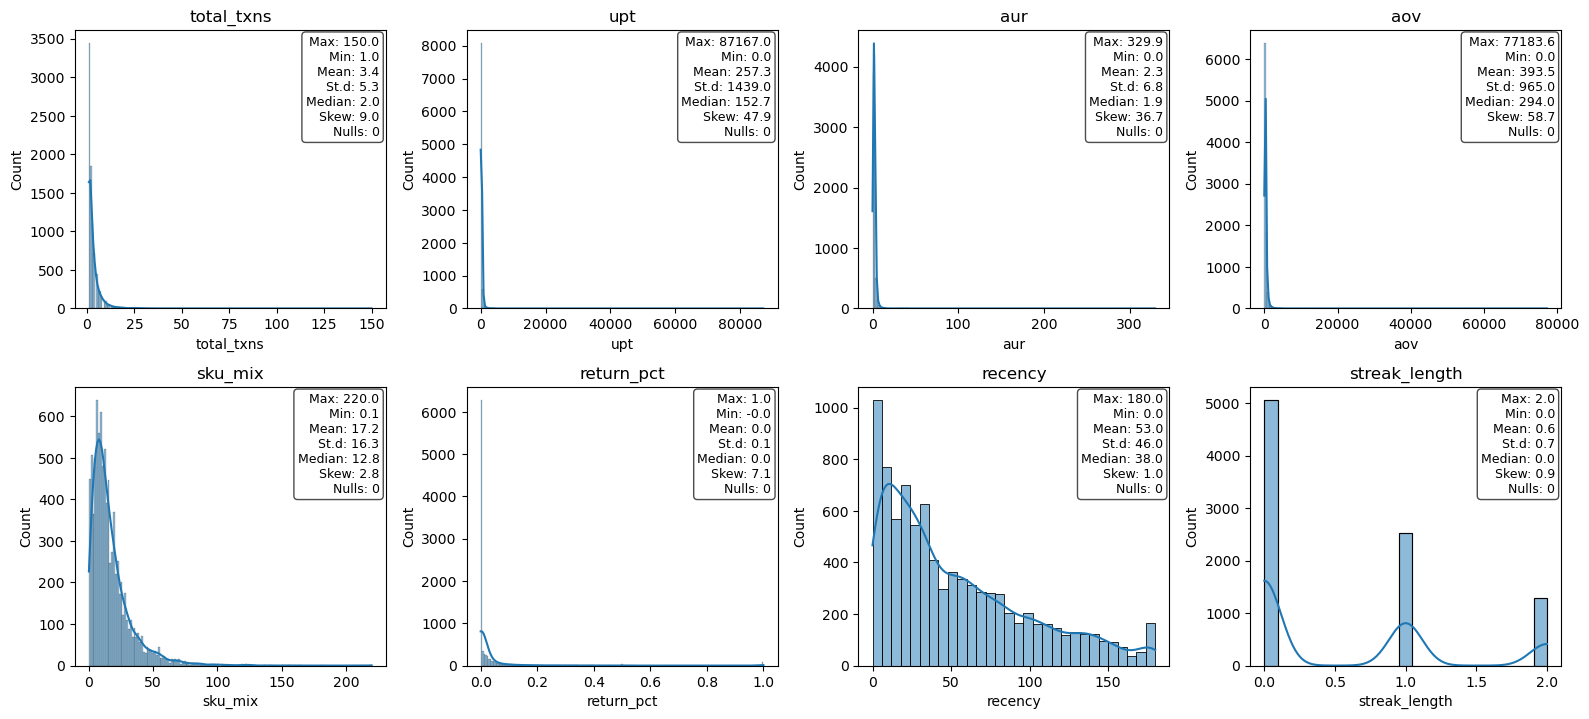

In [8]:
### Plot sistributions of key continuous variable
cont_regressors = ['total_txns', 'upt', 'aur', 'aov', 'sku_mix', 'return_pct', 'recency', 'streak_length']

# Plot distributions
plt.figure(figsize=(16, 14))                                                    # Create a 'canvas'

for i, col in enumerate(cont_regressors, 1):                                    # Loop & for each iteration:
    ax = plt.subplot(4, 4, i)                                                       # i. select a panel
    data = df_180[col]
    
    # Plot
    sns.histplot(data, kde=True, ax=ax)                                                       # ii. create a chart
    ax.set_title(col)                                                               # iii. add title/etc to subplot
    
    # Compute stats
    stats_text = (
        f"Max: {data.max():.1f}\n"
        f"Min: {data.min():.1f}\n"
        f"Mean: {data.mean():.1f}\n"
        f"St.d: {data.std():.1f}\n"
        f"Median: {data.median():.1f}\n"
        f"Skew: {skew(data):.1f}\n"          # Fisher-Pearson coefficient of skewness (|x|>1 --> highly skewed & |x|<0.5 --> fairly symetric)
        f"Nulls: {data.isna().sum():.0f}")

    # Display stats
    ax.text(
        0.98, 0.98, stats_text,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()                                                                          # iv. render prepared figure

The very long tails tails (statistical outliers) & heavy skewness are a byproduct of having two very different customer bases (consumer vs. wholesaler).\
The range & distribution of each variable is within expectations.

Note on recency: Would expect distibution to be flat for single purchase customers but becomes skewed to more recent due to multiple purchase customers.\
Note on streak_length: due to limitations of the data, all customers have a streak of 0 in our first period. Lack of historical data inflates number of 'new customers'

Note: Extreme values are problimatic for convergence & consistency of logistic regression algorhythm.\
Solution - Take the signed natural log of input factors to:  
- Compresses extreme values & stabalize variance --> reduces leverage of exteme values & instability in modeling
- If a variable is highly skewed, its relationship the log-odds of churn is likely non-linear
- Reduces skewness
- Spreads dense peaks  

Improving the performance of the logistic regression model (linearity & outlier influence on coefficients) & gradient boosting model (improved split quality)
- Note: using a signed log transformation due to zero/negative values, achiving the similar tranformation effects as taking the natural log
- For a log tranformation: 1% increase in 𝑥, the signed log odds change by approximately β/100.
- However, for signed-zero shifted-log odds, the effect of x on the log-odds is not constant in percentage terms. Instead, the marginal effect decreases as |𝑥| increases, meaning changes in smaller values of 𝑥 have a larger impact on the model than changes in large values.


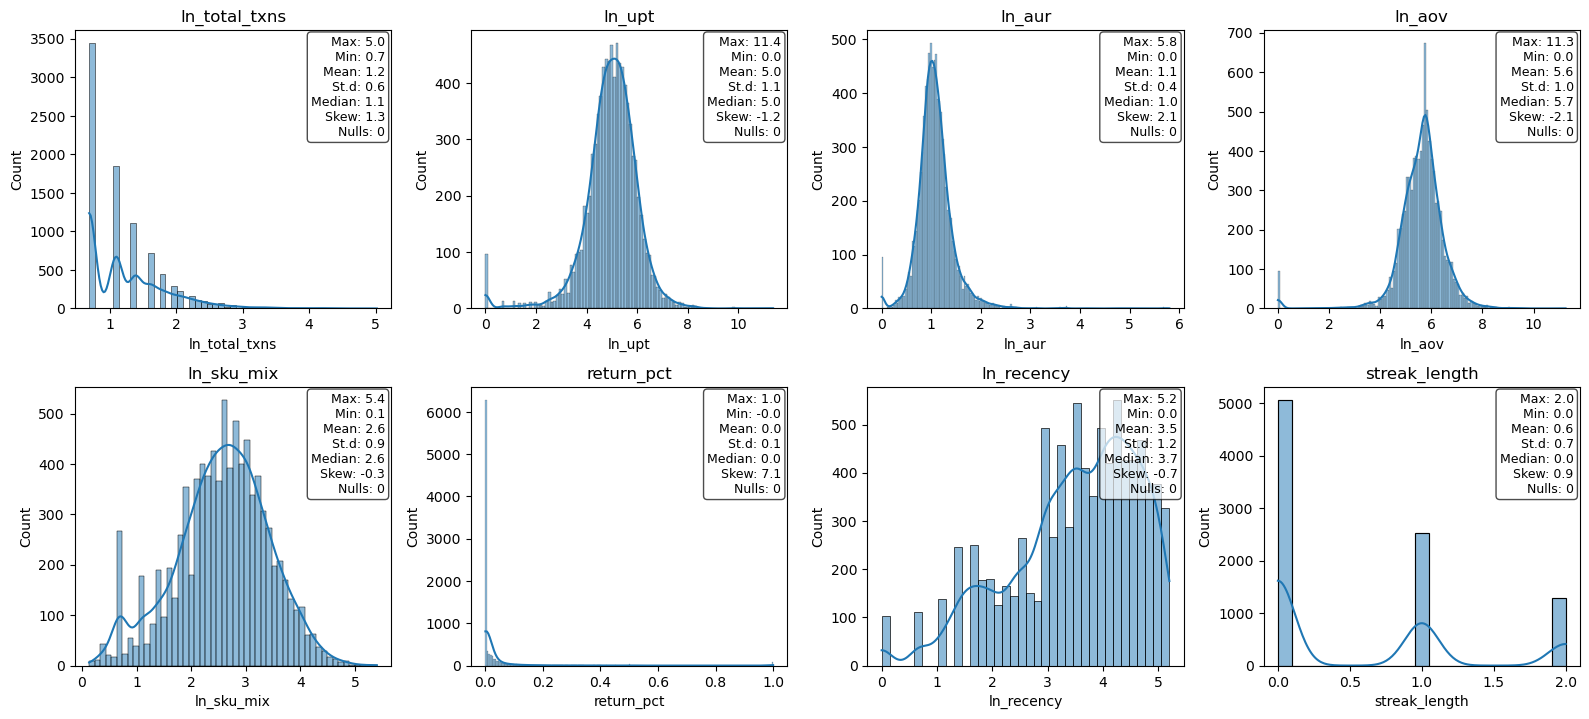

In [9]:
### Take signed natural log of continuous, skewed columns
# (Reduces  impact of extreme outliers, making  variance of the data more constant across its range --> critical for logistic regression algo.)
cols = ['total_txns', 'upt', 'aur', 'aov', 'sku_mix', 'recency']
def sign_log_cols(df, cols):
    """
    Take Signed Logarithmic Transformation {sign(x) * log(1 + |x|)} of continuous, skewed variables.

    Note: Handling Skewed Data with Negatives, is Sign & Zero-Value Preserving
    """
    for c in cols:
        #df.loc[:, f"ln_{c}"] = np.log(df[c])
        df.loc[:, f"ln_{c}"] = np.log(abs(df[c])+1) * np.sign(df[c])
    return df

sign_log_cols(df_180, cols)

### Distribution of key variable
cont_regressors = ['ln_total_txns', 'ln_upt', 'ln_aur', 'ln_aov', 'ln_sku_mix', 'return_pct', 'ln_recency', 'streak_length']

# Re-plot distributions
plt.figure(figsize=(16, 14))                                                    # Create a 'canvas'

for i, col in enumerate(cont_regressors, 1):                                    # Loop & for each iteration:
    ax = plt.subplot(4, 4, i)                                                       # i. select a panel
    
    #data = df_180[col].dropna()#
    data = df_180[col]
    
    # Plot
    sns.histplot(data, kde=True, ax=ax)                                                       # ii. create a chart
    ax.set_title(col)                                                               # iii. add title/etc to subplot
    
    # Compute stats
    stats_text = (
        f"Max: {data.max():.1f}\n"
        f"Min: {data.min():.1f}\n"
        f"Mean: {data.mean():.1f}\n"
        f"St.d: {data.std():.1f}\n"
        f"Median: {data.median():.1f}\n"
        f"Skew: {skew(data):.1f}\n"          # Fisher-Pearson coefficient of skewness (|x|>1 --> highly skewed & |x|<0.5 --> fairly symetric)
        f"Nulls: {data.isna().sum():.0f}")
    # Display stats
    ax.text(
        0.98, 0.98, stats_text,
        transform=ax.transAxes,
        ha='right', va='top',
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.3", fc="white", alpha=0.7))

plt.tight_layout()
plt.show()                                                                          # iv. render prepared figure

After applying signed log transformation skewness is substantially reduced, with compressed tails and improved spread of central regions.

Tranforming the data diminishes the interpretability in the original scale. However, the gains in stability and predictive performance outweigh this limitation.

Notes:
- The spike at zero for UPT, AUR & AOV represent return only customers.
- The spike for ln_sku_mix represents customers who only purchased 1 skew {ln(|1|+1)≃0.7}

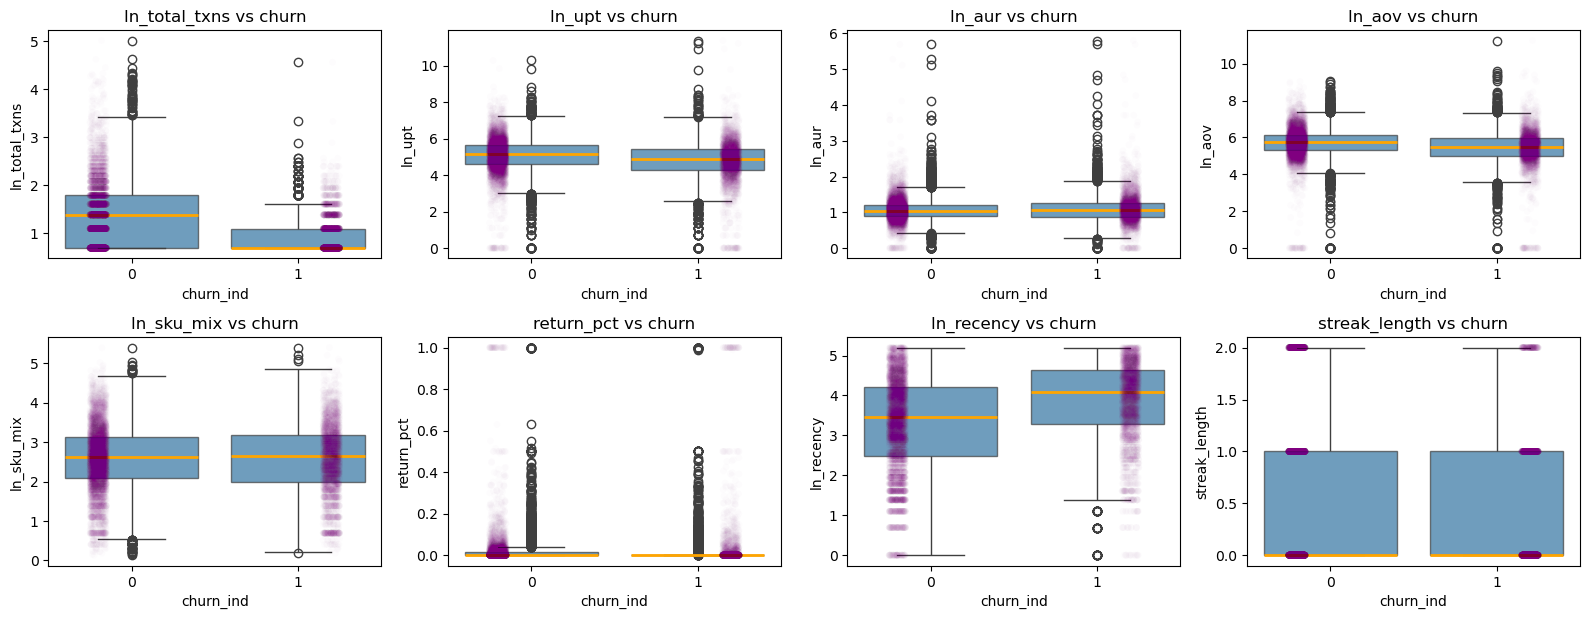

In [10]:
### Compare input factor distributions for churned vs non-chruned customers.
plt.figure(figsize=(16, 12))
for i, col in enumerate(cont_regressors, 1):
    plt.subplot(4, 4, i)
    #ns.boxplot(x="churn_ind", y=col, data=df_180)
    sns.boxplot(data=df_180,
                x="churn_ind",
                y=col,
                medianprops={"color": "orange", "linewidth": 2},
                boxprops={"alpha": 0.7}
                )
    sns.stripplot(
                data=df_180,
                x="churn_ind",
                y=col,
                palette=["purple", "purple"],
                alpha=0.01,
                hue="churn_ind",
                dodge=True,
                legend=False,
                jitter=True

            )
    plt.title(f"{col} vs churn")
plt.tight_layout()
plt.show()

The following can be direved from visually comparing the distributions & medians of each factor for churned vs non-churned customers:
- The largest discrepancies in distributions between groups are for transaction count, followed by recency.\
    (Indicates the majority of churners are single purchase customers)
- There is little to no visual difference between groups for UPT, AUR, AOV, SKU mix, return percent or streak length

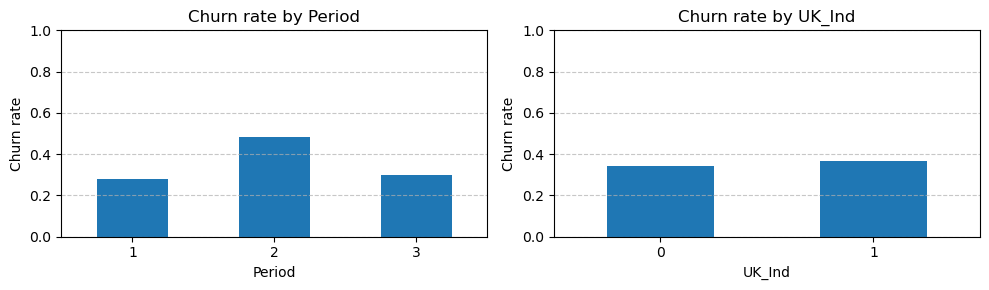

In [11]:
### Plot churn rates across time  geography for trends in seasonality, persistent change in churn accross time or geographical bias.
cat_vars = ["Period", "UK_Ind"]
fig, axes = plt.subplots(1, len(cat_vars), figsize=(10, 3))

for i, col in enumerate(cat_vars):

    churn_rate = df_180.groupby(col)["churn_ind"].mean()
    churn_rate.plot(kind="bar", ax=axes[i], title=f"Churn rate by {col}")
    
    axes[i].set_ylabel("Churn rate")
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].grid(axis='y', linestyle='--', alpha=0.7)
    axes[i].set_ylim(0, 1) 

plt.style.use("default") 
plt.tight_layout()
plt.show()

The spike in churn in Period 2 suggests there might be a seasonality component to churn. However, more historical data is required to determine if this is a pattern that can be modelled or if the spike is do to an isolated incident or economic factor. Geography does not appear to be a significant factor in predicting churn.

## Visualizing relationships between variables

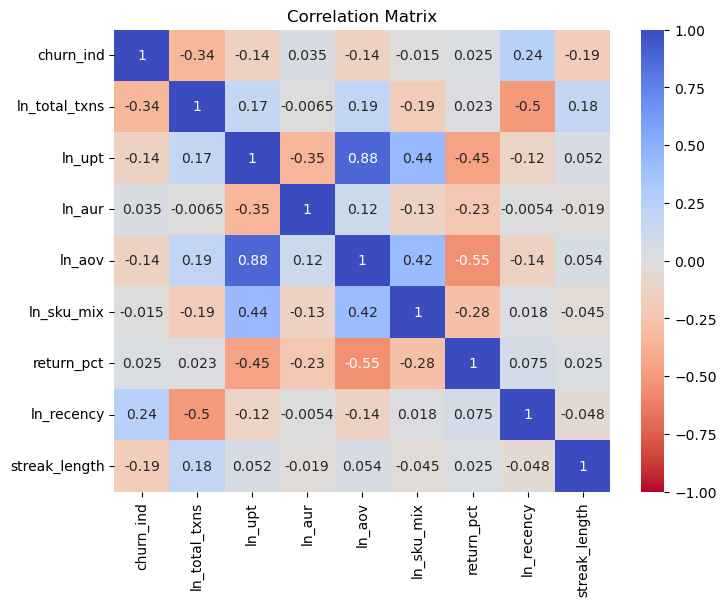

In [ ]:
### Correlation Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(
    df_180[['churn_ind']+ cont_regressors].corr(),
    #mask=mask,
    annot=True,
    cmap="coolwarm_r",
    vmin=-1,
    vmax=1
)
plt.title("Correlation Matrix")
plt.show()

Again, we see Churn is most highly correlated with transaction count (frequency) as well as recency.\
Note: Frequency & recency are moderately correlated with each other which is expected \
(if a customer makes multiple purchases over a period, it is more likely that one of those purchases will be closer to the end of the period).\
\
AUR, SKU mix, & return percentage appear to be almost completely uncorrelated with Churn.

There is an issue of multicolinearity between UPT, AUR & AOV. Therefore, one of these needs to be removed. 

In [13]:
### A correlation matrix was used to assess multicollinearity among predictors.
# Remove AOV as it is the product of AUR & UPT 
cont_regressors.remove('ln_aov')

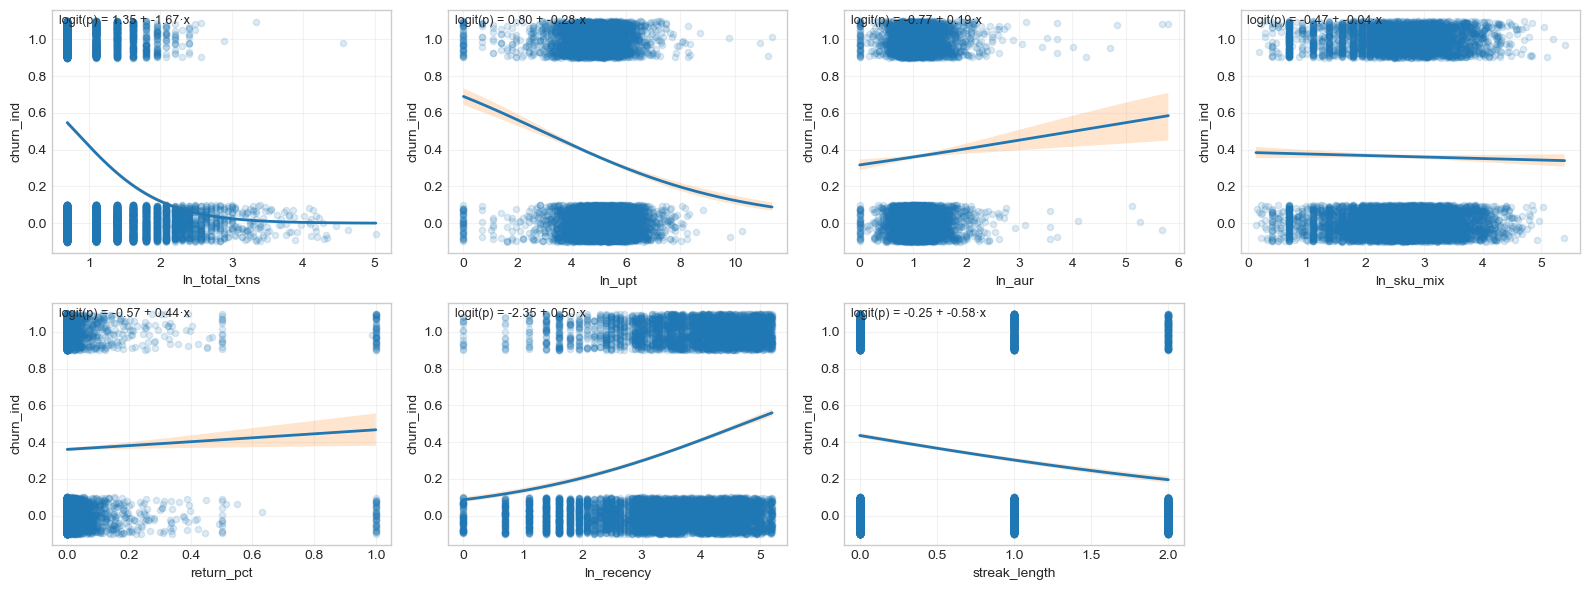

In [ ]:
### Univariate partial dependence logistic regression plots
# Define subplot grid
n_cols = 4
n_rows = int(np.ceil(len(cont_regressors) / 4))                         # np.ceil rounds up to the nearest integer
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))      # Create figure with a grid of subplots
axes = axes.flatten() # Flatten axes array so we can index it easily (1D instead of 2D)
for i, col in enumerate(cont_regressors):
    ax = axes[i]  # Select subplot axis
    x = df_180[col]
    y = df_180['churn_ind']

    # Fit logistic regression
    X = sm.add_constant(x) # Add intercept term
    model = sm.Logit(y, X).fit(disp=False)                              # Fit model (.fit=estimate coeficcients // disp=False suppresses print output)

    # Create grid of x values
    xg = np.linspace(np.min(x), np.max(x), 300)                   # Plot 300 points from min to max x to create a smooth line

    # Compute predicted probabilities
    Xg = sm.add_constant(xg)        # Add constant for prediction
    eta = Xg @ model.params         # Linear predictor: eta = Xβ        # Note: @ = matrix multiplication ()
    p = 1 / (1 + np.exp(-eta))      # Logistic function: p = 1 / (1 + e^-eta) --> converts linear predictor to a probability

    # Compute 95% confidence interval
    cov = model.cov_params()        # Covariance matrix of coefficients
    # Standard error of linear predictor
    se_eta = np.sqrt(np.sum((Xg @ cov) * Xg, axis=1))
    # Lower and upper bounds (converted to probability scale)
    z = 1.96                        # z-score for 95% CI
    lo = 1 / (1 + np.exp(-(eta - z * se_eta)))
    hi = 1 / (1 + np.exp(-(eta + z * se_eta)))

    # Add jitter to churn_ind for clearer visualization of data density
    rng = np.random.default_rng(0)
    yj = y + rng.uniform(-0.1, 0.1, size=len(y))

    # Create plots
    ax.scatter(x, yj, alpha=0.15, s=20)                         # Scatter (data points)
    ax.plot(xg, p, linewidth=2, label="Logistic fit")           # Logistic curve
    ax.fill_between(xg, lo, hi, alpha=0.2, label="95% CI")      # Confidence band
    ax.set_xlabel(col)
    ax.set_ylabel("churn_ind")
    ax.grid(True, alpha=0.25)

    # Annotate model equation
    b0, b1 = model.params
    ax.text(
        0.02, 0.98,
        f"logit(p) = {b0:.2f} + {b1:.2f}·x",
        transform=ax.transAxes,
        va="top",
        fontsize=9 )


# Remove unused subplots
for j in range(len(cont_regressors), len(axes)):
    fig.delaxes(axes[j])


plt.tight_layout()
plt.show()

Univariate partial dependence plots indicate the following:
1. Transaction count per period (frequency) is the strongest driver of retention/churn. This effect is likely reflected again with the inverse slope of recency.
2. Larger basket size (UPT) is a predictor of lower shurn likelihood.
3. Slight positive slope for AUR suggests higher price point customers are less likely to return. \
    (Both UPT & AUR might reflect the difference between wholesale customers & regular consumers)
4. Return percent, SKU mix & streak length show very low predective power.
5. All relationships are have low seperation (heavy overlap between retained & churned) spanning entire range space. Model is probabilistic & not deterministic.\
    (Therefore, will be difficult to predict 'high confidence' churners)

Churn risk is continuous and diffuse, not concentrated in a clearly separable subset of customers

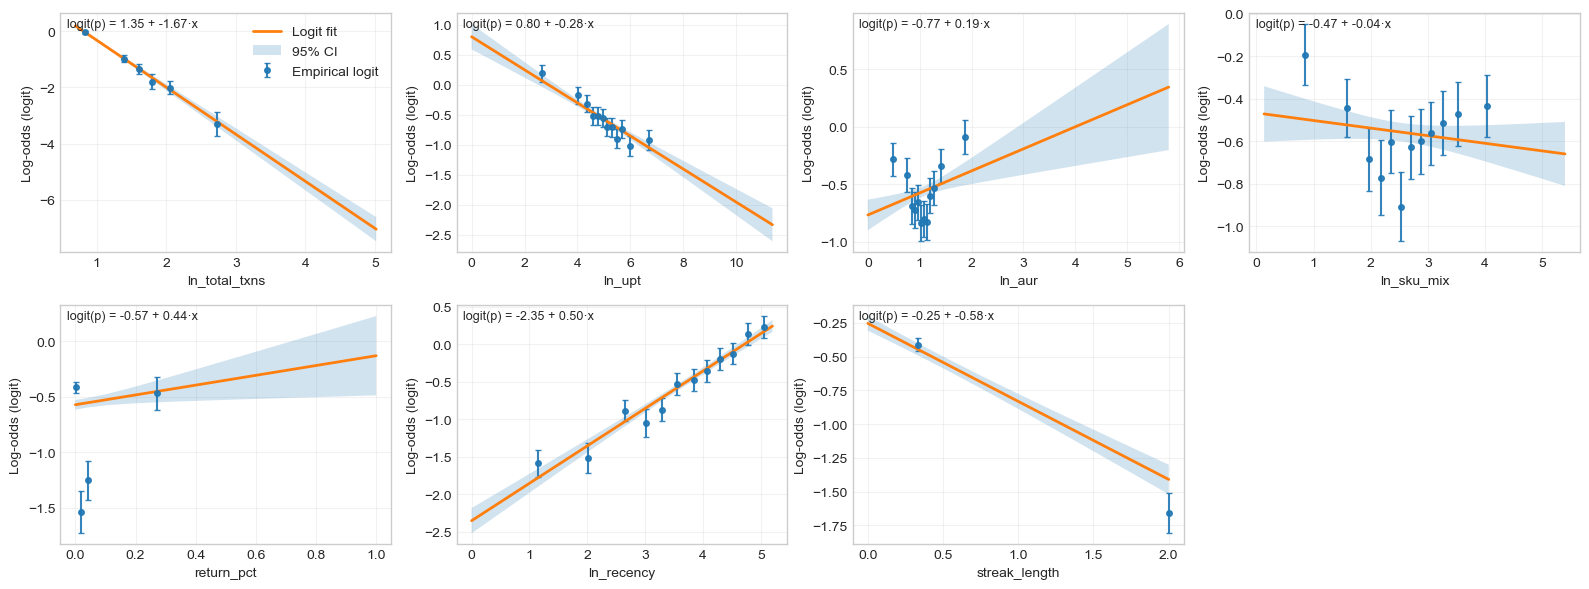

In [ ]:
### Log-odds linearity plots 
# Define subplot grid
#n_cols = 4
#n_rows = int(np.ceil(len(cont_regressors) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 3 * n_rows))
axes = axes.flatten()

# Loop through each feature
for i, col in enumerate(cont_regressors):
    ax = axes[i]
    d = df_180[[col, "churn_ind"]].copy()
    x = d[col]
    y = d["churn_ind"]

    # Fit logistic regression
    X = sm.add_constant(x) # Add intercept term
    model = sm.Logit(y, X).fit(disp=False)                          # Fit model (.fit=estimate coeficcients // disp=False suppresses print output)

    # Create quantile bins for empirical logit
    d["bin"] = pd.qcut(x, q=12, duplicates="drop")
    g = d.groupby("bin", observed=True)

    # Compute bin-level stats
    bin_n = g.size()
    x_bin = g[col].mean()
    p_bin = g["churn_ind"].mean()

    # Convert to empirical log-odds
    p_clip = np.clip(p_bin.to_numpy(), 1e-4, 1 - 1e-4)              # avoid log(0)
    logit_emp = np.log(p_clip / (1 - p_clip))
    # Approximate standard error (delta method)
    se_emp = np.sqrt(1.0 / (bin_n.to_numpy() * p_clip * (1 - p_clip)))
    z = 1.96
    lo_emp = logit_emp - z * se_emp
    hi_emp = logit_emp + z * se_emp

    # Create regression line
    xg = np.linspace(np.min(x), np.max(x), 300)
    Xg = sm.add_constant(xg)
    # Linear predictor (log-odds)
    eta_g = Xg @ model.params
    # Confidence interval for model
    cov = model.cov_params()
    se_eta_g = np.sqrt(np.sum((Xg @ cov) * Xg, axis=1))
    lo_g = eta_g - z * se_eta_g
    hi_g = eta_g + z * se_eta_g

    # Plot everything
    ax.errorbar(                                                    # Empirical logit (binned points + error bars)
        x_bin.to_numpy(),
        logit_emp,
        yerr=[logit_emp - lo_emp, hi_emp - logit_emp],
        fmt="o",
        ms=4,
        capsize=2,
        alpha=0.9,
        label="Empirical logit")
    ax.plot(xg, eta_g, linewidth=2, label="Logit fit")              # Model line
    ax.fill_between(xg, lo_g, hi_g, alpha=0.2, label="95% CI")      # Confidence band
    # Labels
    ax.set_xlabel(col)
    ax.set_ylabel("Log-odds (logit)")
    ax.grid(True, alpha=0.25)
    # Equation annotation
    b0, b1 = model.params
    ax.text(
        0.02, 0.98,
        f"logit(p) = {b0:.2f} + {b1:.2f}·x",
        transform=ax.transAxes,
        va="top",
        fontsize=9)

    # Show legend only on first plot
    if i == 0:
        ax.legend(frameon=False)

# Remove unused subplots
for j in range(len(cont_regressors), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

These plots are to help determine if the relationships between factors and churn are linear in log-odds (assumption for logistic regression).\
(If points are not linear --> indicates factor is either noise or misspecified)

Linearity diagnostics showed that several key predictors (AUR, SKU Mix, Return Pct.) exhibit nonlinear effects, leading to model misspecification in logistic regression. This motivated the use of tree-based models or nonlinear feature transformations (polynomial terms/binning).

# Model Results
-----------------


In [ ]:
## Define function for evaluating model results
def evaluate(df, y_true, y_pred, y_prob, model_name):
    period_length = (df[df['Period'] == df['Period'].min()]['Observation End'][0] - df[df['Period'] == df['Period'].min()]['Observation Start'][0]).days
    print(f"\n=== {model_name} : {period_length} days ===")
    print(f"Accuracy : {accuracy_score(y_true, y_pred):.3f}")
    print(f"Precision: {precision_score(y_true, y_pred):.3f}")
    print(f"Recall   : {recall_score(y_true, y_pred):.3f}")
    print(f"F1 Score : {f1_score(y_true, y_pred):.3f}")
    print(f"ROC-AUC  : {roc_auc_score(y_true, y_prob):.3f}")


#35% churn 180 days
#42% churn 90 days
dft = df_180.copy()

# Keep only rows where churn is defined (Periods 1–3) 
dft = dft[dft['Period'] <= dft['Period'].max()]

# Train = Periods 1 and 2
train_df = dft[dft['Period'] < dft['Period'].max()].copy()

# Test = Period 3 (most recent labeled period)
test_df = dft[dft['Period'] == dft['Period'].max()].copy()


# Select imput factors for modeling
regressors = ['ln_total_txns', 'ln_upt', 'ln_aur', 'ln_sku_mix','ln_recency',
              'return_pct', 'streak_length', 'UK_Ind', 
              'cx_single_purchase', 'cx_return_only', 'cx_return_txn']

X_train = train_df[regressors]
y_train = train_df['churn_ind']

X_test = test_df[regressors]
y_test = test_df['churn_ind']

# Fill missing values
#X_train = X_train.fillna(0)
#X_test = X_test.fillna(0)

## Logistic Regression

In [19]:
##################
# Scale for Logistic Regression
##################
from sklearn.preprocessing import StandardScaler

binary_features = [
    col for col in X_train.columns
    if X_train[col].dropna().nunique() == 2
]

numeric_features = [
    col for col in X_train.columns
    if col not in binary_features
]

X_train_scaled = X_train.copy() 
X_train_scaled[numeric_features] = StandardScaler().fit_transform(X_train[numeric_features])
X_test_scaled = X_test.copy() 
X_test_scaled[numeric_features] = StandardScaler().fit_transform(X_test[numeric_features])

In [20]:
X_train

,UK_Ind,sale_frequency,streak_length,recency,cx_single_purchase,cx_return_only,return_pct,ln_total_txns,ln_aur,ln_aov,ln_sku_mix
0,1,1,0,104,1,0,-0.00,0.69,1.86,3.33,1.79
1,1,1,1,167,1,0,-0.00,0.69,2.14,4.97,3.00
3,0,2,0,5,0,0,-0.00,1.10,0.95,6.50,3.58
6,0,1,0,76,1,0,-0.00,0.69,0.47,5.40,3.00
9,0,1,0,46,1,0,-0.00,0.69,1.18,6.97,3.85
...,...,...,...,...,...,...,...,...,...,...,...
12345,1,1,0,117,1,0,-0.00,0.69,1.29,5.93,2.48
12346,1,1,0,180,1,0,-0.00,0.69,1.54,6.03,2.83
12347,1,1,1,114,1,0,0.11,1.10,0.99,6.73,3.31
12348,1,1,0,28,1,0,-0.00,0.69,0.90,6.98,4.01


In [21]:
X_test

,UK_Ind,sale_frequency,streak_length,recency,cx_single_purchase,cx_return_only,return_pct,ln_total_txns,ln_aur,ln_aov,ln_sku_mix
2,1,1,2,144,1,0,0.50,1.10,0.71,11.25,0.41
4,0,3,1,2,0,0,-0.00,1.39,0.92,6.21,3.01
7,0,3,1,67,0,0,-0.00,1.39,0.44,5.97,2.08
12,0,1,0,129,1,0,-0.00,0.69,0.92,5.69,2.83
15,0,4,1,81,0,0,0.16,1.79,1.27,5.08,1.76
...,...,...,...,...,...,...,...,...,...,...,...
12322,1,1,0,76,1,0,-0.00,0.69,1.27,3.95,0.69
12330,1,0,1,137,0,1,1.00,0.69,0.00,0.00,0.69
12336,1,1,1,96,1,0,-0.00,0.69,1.61,5.20,2.40
12342,1,5,2,19,0,0,-0.00,1.79,0.95,4.68,3.37


In [22]:
df_180['churn_ind'].sum()/df_180['churn_ind'].count()

np.float64(0.3638314695583418)

In [23]:
## fit logistic regression
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=2000)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
y_prob_lr = log_reg.predict_proba(X_test_scaled)[:, 1]


## Fit gradiant boost
from sklearn.ensemble import HistGradientBoostingClassifier

gb = HistGradientBoostingClassifier(
    max_iter=300,
    max_depth=5,
    learning_rate=0.05
)

gb.fit(X_train, y_train)
y_pred_gb = gb.predict(X_test)
y_prob_gb = gb.predict_proba(X_test)[:, 1]


# Results
evaluate(dft, y_test, y_pred_lr, y_prob_lr, "Logistic Regression")
evaluate(dft, y_test, y_pred_gb, y_prob_gb, "Gradient Boosting (XGBoost)")


=== Logistic Regression : 180 days ===
Accuracy : 0.661
Precision: 0.453
Recall   : 0.681
F1 Score : 0.544
ROC-AUC  : 0.700

=== Gradient Boosting (XGBoost) : 180 days ===
Accuracy : 0.654
Precision: 0.444
Recall   : 0.652
F1 Score : 0.528
ROC-AUC  : 0.714


In [24]:
import statsmodels.api as sm

X_train_sm = sm.add_constant(X_train_scaled)
model = sm.Logit(y_train, X_train_sm)
result = model.fit()

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.580356
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:              churn_ind   No. Observations:                 6175
Model:                          Logit   Df Residuals:                     6163
Method:                           MLE   Df Model:                           11
Date:                Tue, 07 Apr 2026   Pseudo R-squ.:                  0.1338
Time:                        11:46:34   Log-Likelihood:                -3583.7
converged:                       True   LL-Null:                       -4137.4
Covariance Type:            nonrobust   LLR p-value:                1.513e-230
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 -0.8466      0.116     -7.303      0.000      -1.074      -0.619
UK_In

In [25]:
threshold = 0.8
mask = y_prob_gb > threshold

from sklearn.metrics import precision_score

precision_high = precision_score(y_test[mask], y_pred_gb[mask])     # precision = tp / (tp + fp)
coverage = mask.mean()

print(f"Coverage: {coverage:.2%}")
print(f"Precision: {precision_high:.3f}", "\n")

################


thresholds = np.linspace(0.5, 0.95, 10)

for t in thresholds:
    mask = y_prob_gb > t
    if mask.sum() == 0:
        continue
    
    precision = precision_score(y_test[mask], y_pred_gb[mask])
    coverage = mask.mean()
    
    print(f"Threshold={t:.2f} | Coverage={coverage:.2%} | Precision={precision:.3f}")


# model has limited ranking power. only slightly better than random for top 4% ... this is pretty bad
# ex. “Baseline churn is 30%, but targeted group is 51% → ~1.7x higher risk” 

Coverage: 1.16%
Precision: 0.516 

Threshold=0.50 | Coverage=43.58% | Precision=0.444
Threshold=0.55 | Coverage=34.73% | Precision=0.455
Threshold=0.60 | Coverage=24.87% | Precision=0.462
Threshold=0.65 | Coverage=15.50% | Precision=0.453
Threshold=0.70 | Coverage=8.59% | Precision=0.448
Threshold=0.75 | Coverage=3.73% | Precision=0.510
Threshold=0.80 | Coverage=1.16% | Precision=0.516
Threshold=0.85 | Coverage=0.22% | Precision=0.500


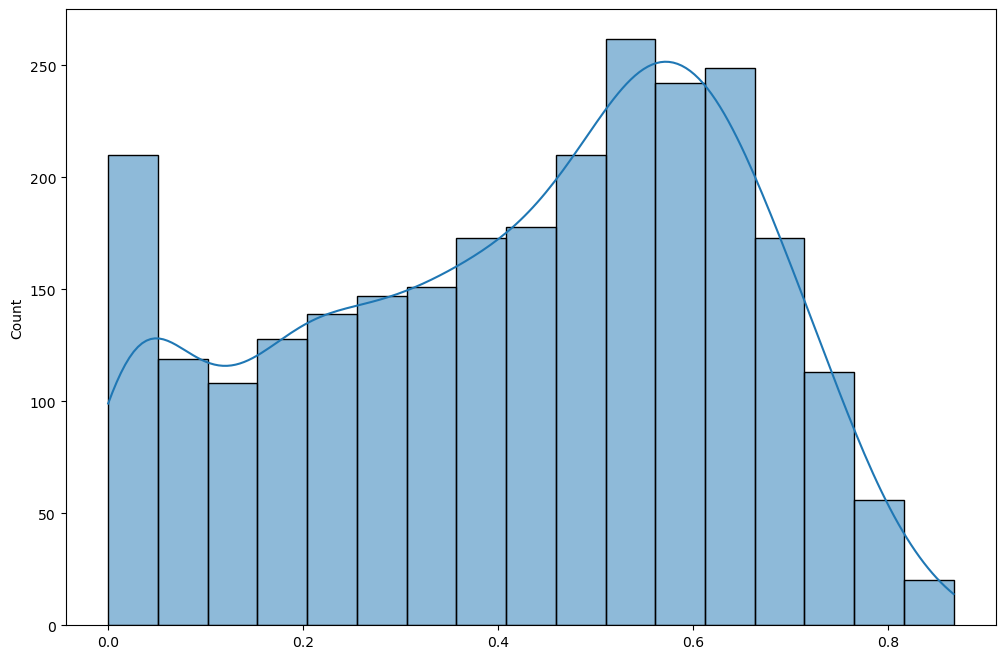

In [26]:
## Plot predicted probability

plt.figure(figsize=(12, 8))
sns.histplot(y_prob_gb, kde=True)
plt.show()

## Gradient Boosting Model

### Hyperparameter Tuning - Random Search

In [27]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import roc_auc_score, classification_report

param_distributions = {
    ### Function Shape
    "learning_rate": loguniform(0.01, 0.2),                     # Contribution of each tree
    "n_estimators": randint(50, 800),                           # Number of boosting stages/trees
    ### Tree shapes
    "max_depth": randint(3, 9),                                  # Deeper trees capture more interactions (but overfit quickly)
    "min_samples_split": loguniform(0.001, 0.1),                # Should depend on dataset size (min split log spacespace from 0.1% to 10% of samples)
    "min_samples_leaf": loguniform(0.001, 0.05),                # Minimum samples in each each leaf
    ### 
    "subsample": uniform(0.5, 1-0.5),                               # Fraction of rows to use for each tree
    #"max_features": ["sqrt", "log2", None],                    # Use only a subset of features for each tree (avoids single factor dominating each tree)
    "max_features": [None]                                      # Use none if feature set is small (<20)
}


search = RandomizedSearchCV(
    estimator=GradientBoostingClassifier(random_state=1,
                                        n_iter_no_change=15,
                                        validation_fraction=0.1,
                                        tol=1e-4),
    param_distributions=param_distributions,
    n_iter=60,
    scoring="average_precision",                    # Area under Precision-Recall curve
            #"recall"                               # To catch them all - use if missing a churn cost much higher than false positive
            #"f1"                                   # Balance between Precision and Recall
            #"roc_auc"                              # Standard - Ability to distinguish classes but can be misleadingly high if data is imbalanced
    # Cross validation splits your data into n chunks. It trains on n-1 and tests on 1
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=1), 
    random_state=1,
    n_jobs=-1,
    verbose=1,                          # Show progress bar to see how many fits are left
    refit=True,                         # After the search finds the best parameters, take those settings & retrains model on entire dataset
)

search.fit(X_train, y_train)

print("Best CV Average Precision:", search.best_score_)
print("Best params:", search.best_params_)

best_model = search.best_estimator_
proba_test = best_model.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, proba_test))
print(classification_report(y_test, (proba_test >= 0.5).astype(int)))


Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV Average Precision: 0.5946309696389308
Best params: {'learning_rate': np.float64(0.03487852712623489), 'max_depth': 7, 'max_features': None, 'min_samples_leaf': np.float64(0.038404930262862944), 'min_samples_split': np.float64(0.0018040513535031988), 'n_estimators': 695, 'subsample': np.float64(0.5733779454085566)}
Test ROC-AUC: 0.7291636188739367
              precision    recall  f1-score   support

           0       0.82      0.68      0.74      1883
           1       0.46      0.65      0.54       795

    accuracy                           0.67      2678
   macro avg       0.64      0.66      0.64      2678
weighted avg       0.71      0.67      0.68      2678



Interpretation
- Precision (0.46): When the model flags a customer as a churner, it is only right 46% of the time --> (many false positives).
- Recall (0.65): Out of all actually churnedrs, model caught 65% of them. Missing ~35% (False Negatives).
- F1-Score (0.54): Harmonic mean of the two scores

- Accuracy (0.67): To be ignored. If just guessed "zero churners," we'd get ~70% accuracy. Model is currently at 67%, meaning it’s actually working harder to find the churners at the cost of overall accuracy.

In [28]:
# Just a faster verison of the same thing with HistGradientBoostingClassifier
n = X_train.shape[0]
# Calculate absolute row counts for your bounds
# Ensure the min is at least 1 and the max is at least min + 1
min_leaf_lower = max(1, int(n * 0.001)) 
min_leaf_upper = max(min_leaf_lower + 1, int(n * 0.05))
max_leaf_upper = max(16, min(255, n // 100))


# HGBC grows trees leaf-wise (best-first), whereas GBC typically grows them level-wise. 
# Leaf-wise growth is more flexible and efficient for large datasets but requires max_leaf_nodes to be carefully tuned to prevent deep, overfit branches.
hist_param_distributions = {
    ### Function Shape
    "learning_rate": loguniform(0.01, 0.3),                         # Contribution of each tree (use wider range for HGBC)
    "max_iter": randint(100, 1000),                                 # Number of boosting stages/trees (Note: max_iter == n_estimators) set high due to early_stopping=True.
    
    ### Tree shapes
    # Don't let trees have more leaves than 1/100th of your data, maxed at 255
    "max_leaf_nodes": randint(15, max_leaf_upper),                  # HGBC prioritize max_leaf_nodes over max_depth
    "min_samples_leaf": randint(min_leaf_lower, min_leaf_upper),    # Minimum samples in each each leaf

    # HGBC uses its internal histogram logic and early stopping to manage variance instead of row-based subsampling.
    # max_bins defaults to 255 - Test if "coarser" features help generalization
    "max_bins": randint(32, 255),                                   # Binning granularity

    # Prevent overfitting by penalizing large weights - adds penalty proportional to the square of the magnitude of the model's coefficients to the loss function
    "l2_regularization": loguniform(1e-6, 10.0)  
}


hist_search = RandomizedSearchCV(
                estimator=HistGradientBoostingClassifier(
                random_state=1,
                early_stopping=True,
                validation_fraction=0.1,            # For early stop, model needs to test itself on data it hasn't seen. It trains on 90%, then checks its score on this 10%
                n_iter_no_change=15,                # How many trees the model is willing to build without seeing an improvement before it gives up
                tol=1e-4                            # "Tolerance" // what counts as a "real" improvement
                    # Note: If learning_rate is extremely small (~0.001), model might improve so slowly that it triggers tol and stops too early. 
                    # If using tiny learning rate, one should also make tol smaller or n_iter_no_change larger. 
                ),
    param_distributions=hist_param_distributions,
    n_iter=60,
    scoring="average_precision",                    # Area under Precision-Recall curve
            #"recall"                               # To catch them all - use if missing a churn cost much higher than false positive
            #"f1"                                   # Balance between Precision and Recall
            #"roc_auc"                              # Standard - Ability to distinguish classes but can be misleadingly high if data is imbalanced
    # Cross validation splits your data into n chunks. It trains on n-1 and tests on 1
    cv= StratifiedKFold(n_splits=5, shuffle=True, random_state=1), 
    random_state=1,
    n_jobs=-1,
    verbose=1,                          # Show progress bar to see how many fits are left
    refit=True,                         # After the search finds the best parameters, take those settings & retrains model on entire dataset
)

hist_search.fit(X_train, y_train)

print("Best CV Average Precision:", hist_search.best_score_)
print("Best params:", hist_search.best_params_)

best_model_hist = hist_search.best_estimator_
proba_test_hist = best_model_hist.predict_proba(X_test)[:, 1]
print("Test ROC-AUC:", roc_auc_score(y_test, proba_test_hist))
print(classification_report(y_test, (proba_test_hist >= 0.5).astype(int)))

Fitting 5 folds for each of 60 candidates, totalling 300 fits
Best CV Average Precision: 0.5932763361797716
Best params: {'l2_regularization': np.float64(0.023345861532847307), 'learning_rate': np.float64(0.09458866124759048), 'max_bins': 57, 'max_iter': 467, 'max_leaf_nodes': 49, 'min_samples_leaf': 288}
Test ROC-AUC: 0.721827540022111
              precision    recall  f1-score   support

           0       0.82      0.67      0.74      1883
           1       0.45      0.65      0.54       795

    accuracy                           0.66      2678
   macro avg       0.64      0.66      0.64      2678
weighted avg       0.71      0.66      0.68      2678



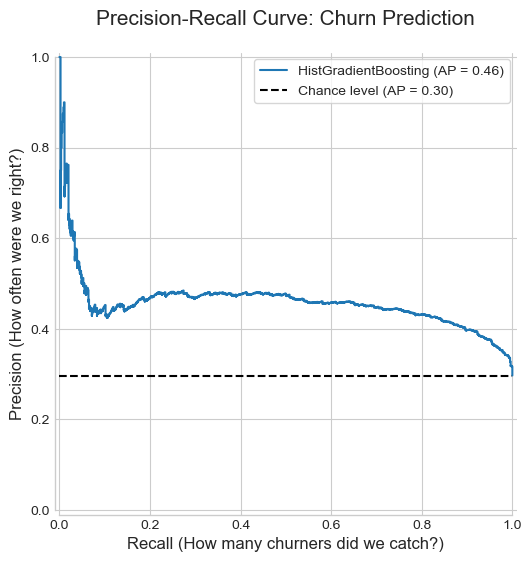

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import PrecisionRecallDisplay

# Set a nice style (optional)
plt.style.use('seaborn-v0_8-whitegrid') 

# 1. Create the plot using the best model from your search
# This automatically handles probability calculation and threshold sweeping
fig, ax = plt.subplots(figsize=(8, 6))

display = PrecisionRecallDisplay.from_estimator(
    hist_search.best_estimator_, 
    X_test, 
    y_test, 
    name="HistGradientBoosting",
    plot_chance_level=True,  # Shows the baseline for imbalanced data
    despine=True,            # Removes top/right borders for a cleaner look
    ax=ax
)

# 2. Add custom styling to make it "pretty"
ax.set_title("Precision-Recall Curve: Churn Prediction", fontsize=15, pad=20)
ax.set_xlabel("Recall (How many churners did we catch?)", fontsize=12)
ax.set_ylabel("Precision (How often were we right?)", fontsize=12)
ax.legend(loc="upper right", frameon=True)

plt.show()

In [30]:
### Should look at a different threshold for proba_test_hist >= 0.5).

A steep drop-off at the beginning suggests the model is struggling even with its most "certain" predictions.

### Hyperparameter Tuning - Bayesian Optimization


In [31]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [32]:
# Define objective function (the thing we are optimizing with bayesian decent)
def objective_hgb(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "max_iter": trial.suggest_int("max_iter", 100, 1000),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, max_leaf_upper),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", min_leaf_lower, min_leaf_upper),
        "max_bins": trial.suggest_int("max_bins", 32, 255),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-6, 10.0, log=True),
    }

    model = HistGradientBoostingClassifier(
        **params,
        random_state=1,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=15,
        tol=1e-4
    )

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=1),
        scoring="average_precision",
        n_jobs=-1
    )

    return scores.mean()            # Optuna needs single scalar to optimize

# Run the study (study == entire optimization process)
    # Study contains all trials (each hyperparameter combo), scores, best result so far & search strategy.
study_hgb = optuna.create_study(direction="maximize")

# Each trial hyperparameters selected strategically, calls objective function (getting score), & informs model for performance improvements
study_hgb.optimize(objective_hgb, n_trials=50, show_progress_bar=True)

# Fit final model
best_hgb_bayes = HistGradientBoostingClassifier(
    **study_hgb.best_params,
    random_state=1,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    tol=1e-4
)

best_hgb_bayes.fit(X_train, y_train)

proba_test_hgb_bayes = best_hgb_bayes.predict_proba(X_test)[:, 1]
pred_test_hgb_bayes = (proba_test_hgb_bayes >= 0.5).astype(int)

print("Test Average Precision:", average_precision_score(y_test, proba_test_hgb_bayes))
print("Test ROC-AUC:", roc_auc_score(y_test, proba_test_hgb_bayes))
print(classification_report(y_test, pred_test_hgb_bayes))

[I 2026-04-07 11:47:11,967] A new study created in memory with name: no-name-10a9db6a-175d-4cf4-8144-d3627256cea1
Best trial: 0. Best value: 0.586333:   2%|▏         | 1/50 [00:00<00:11,  4.37it/s]

[I 2026-04-07 11:47:12,197] Trial 0 finished with value: 0.586333137682314 and parameters: {'learning_rate': 0.04006000016713144, 'max_iter': 499, 'max_leaf_nodes': 32, 'min_samples_leaf': 214, 'max_bins': 37, 'l2_regularization': 0.01666921629623929}. Best is trial 0 with value: 0.586333137682314.


Best trial: 1. Best value: 0.591656:   4%|▍         | 2/50 [00:00<00:12,  3.77it/s]

[I 2026-04-07 11:47:12,488] Trial 1 finished with value: 0.5916557139480749 and parameters: {'learning_rate': 0.0335744795519788, 'max_iter': 795, 'max_leaf_nodes': 20, 'min_samples_leaf': 305, 'max_bins': 214, 'l2_regularization': 0.000297775369374855}. Best is trial 1 with value: 0.5916557139480749.


Best trial: 1. Best value: 0.591656:   6%|▌         | 3/50 [00:00<00:15,  2.95it/s]

...

[I 2026-04-07 11:47:22,948] Trial 47 finished with value: 0.5887533691075946 and parameters: {'learning_rate': 0.022625246894115044, 'max_iter': 943, 'max_leaf_nodes': 22, 'min_samples_leaf': 263, 'max_bins': 248, 'l2_regularization': 0.439508655259915}. Best is trial 42 with value: 0.5920903689053497.


Best trial: 42. Best value: 0.59209:  98%|█████████▊| 49/50 [00:11<00:00,  3.71it/s]

[I 2026-04-07 11:47:23,182] Trial 48 finished with value: 0.5905689433762419 and parameters: {'learning_rate': 0.04813744004801276, 'max_iter': 505, 'max_leaf_nodes': 26, 'min_samples_leaf': 279, 'max_bins': 225, 'l2_regularization': 2.1285542666192114}. Best is trial 42 with value: 0.5920903689053497.


Best trial: 42. Best value: 0.59209: 100%|██████████| 50/50 [00:11<00:00,  4.35it/s]


[I 2026-04-07 11:47:23,450] Trial 49 finished with value: 0.5856453175119355 and parameters: {'learning_rate': 0.03710311202571863, 'max_iter': 369, 'max_leaf_nodes': 46, 'min_samples_leaf': 122, 'max_bins': 183, 'l2_regularization': 0.8792432311246504}. Best is trial 42 with value: 0.5920903689053497.
Test Average Precision: 0.4584802045461822
Test ROC-AUC: 0.7262293877360161
              precision    recall  f1-score   support

           0       0.82      0.68      0.74      1883
           1       0.46      0.66      0.54       795

    accuracy                           0.67      2678
   macro avg       0.64      0.67      0.64      2678
weighted avg       0.72      0.67      0.68      2678



/var/folders/5q/s0lxsnr51f340fp9gk4pxq2h0000gn/T/ipykernel_20124/839457838.py:7: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_test)


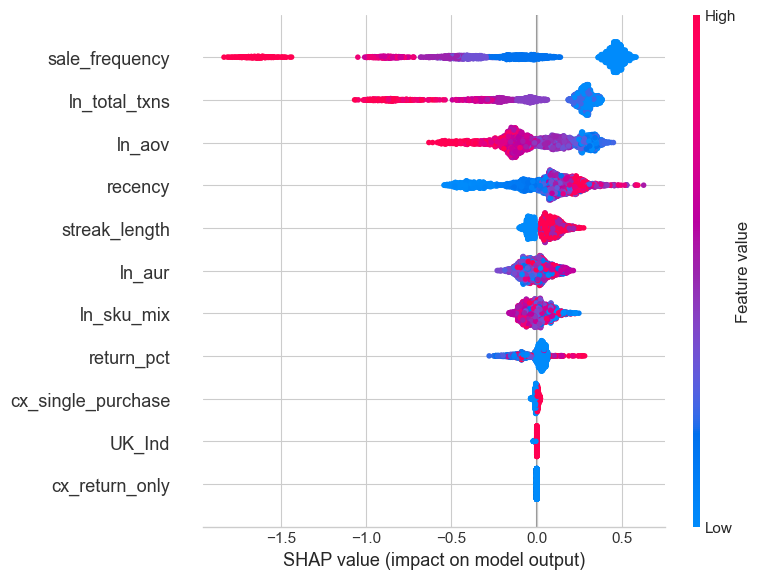

{'min_samples_leaf': np.float64(0.8423251964950843),
 'max_leaf_nodes': np.float64(0.06337547021430141),
 'learning_rate': np.float64(0.04692336411701887),
 'max_iter': np.float64(0.042772189938407965),
 'max_bins': np.float64(0.004473530516428814),
 'l2_regularization': np.float64(0.00013024871875867315)}

In [33]:
# Basic feature importance check 
import shap

explainer = shap.Explainer(best_hgb_bayes)
shap_values = explainer(X_test)

shap.summary_plot(shap_values, X_test)

# Order of hyperparameter importance 
optuna.importance.get_param_importances(study_hgb)

In [34]:
def evaluate_model(model, X_test, y_test, threshold=0.5, name="Model"):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)

    print(f"\n=== {name} ===")
    print("Test Average Precision:", average_precision_score(y_test, proba))
    print("Test ROC-AUC:", roc_auc_score(y_test, proba))
    print(classification_report(y_test, pred))

evaluate_model(best_model, X_test, y_test, name="Gradient Boosting Classifier")
evaluate_model(best_model_hist, X_test, y_test, name="Hist Gradient Boosting Classifier")
evaluate_model(best_hgb_bayes, X_test, y_test, name="Bayesian HGBC")


=== Gradient Boosting Classifier ===
Test Average Precision: 0.4633830760332713
Test ROC-AUC: 0.7291636188739367
              precision    recall  f1-score   support

           0       0.82      0.68      0.74      1883
           1       0.46      0.65      0.54       795

    accuracy                           0.67      2678
   macro avg       0.64      0.66      0.64      2678
weighted avg       0.71      0.67      0.68      2678


=== Hist Gradient Boosting Classifier ===
Test Average Precision: 0.45947141540113723
Test ROC-AUC: 0.721827540022111
              precision    recall  f1-score   support

           0       0.82      0.67      0.74      1883
           1       0.45      0.65      0.54       795

    accuracy                           0.66      2678
   macro avg       0.64      0.66      0.64      2678
weighted avg       0.71      0.66      0.68      2678


=== Bayesian HGBC ===
Test Average Precision: 0.4584802045461822
Test ROC-AUC: 0.7262293877360161
              

# Comparing model results
---------------------------

## ~Interpreting SHAP values

## ~Customer Segmentation

# ~Aditional Analysis: Temporal Factors
-----------------------------------